In [5]:
import pandas as pd
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

server = r"SUFILAPTOP\SQLEXPRESS"
database = "Inventory"

driver = quote_plus("ODBC Driver 17 for SQL Server")

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes"
)

print("✅ Connected Successfully")

begin_inventory = pd.read_sql(text("SELECT * FROM [dbo].[begin_inventory]"), engine)
end_inventory = pd.read_sql(text("SELECT * FROM [dbo].[end_inventory]"), engine)
purchases = pd.read_sql(text("SELECT * FROM [dbo].[purchases]"), engine)
purchase_prices = pd.read_sql(text("SELECT * FROM [dbo].[purchase_prices]"), engine)
sales = pd.read_sql(text("SELECT * FROM [dbo].[sales]"), engine)
vendor_invoice = pd.read_sql(text("SELECT * FROM [dbo].[vendor_invoice]"), engine)

print("✅ All tables imported successfully!")

tables = {
    "BeginInventory": begin_inventory,
    "EndInventory": end_inventory,
    "Purchases": purchases,
    "PurchasePrices": purchase_prices,
    "Sales": sales,
    "VendorInvoice": vendor_invoice
}

for name, df in tables.items():
    print(f"\n{name}")
    print(f"Shape: {df.shape}")

✅ Connected Successfully
✅ All tables imported successfully!

BeginInventory
Shape: (206529, 9)

EndInventory
Shape: (224489, 9)

Purchases
Shape: (2372474, 16)

PurchasePrices
Shape: (12260, 9)

Sales
Shape: (12825363, 14)

VendorInvoice
Shape: (5543, 10)


In [151]:
# all libraries used
import pandas as pd
from scipy.stats import pearsonr
from scipy.stats import shapiro
from scipy.stats import normaltest
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

# **1: CORRELATION ANALYSIS**

# **Correlation Between Purchase Quantity and Unit Cost**
# **Business Objective:**

- **Determine whether purchasing larger quantities results in lower unit costs.**

In [15]:
# Vendor Dataset
vendor_purchase = (
    purchases
    .groupby(['VendorNumber', 'VendorName'], as_index=False)
    .agg(
        Total_Quantity=('Quantity', 'sum'),
        Avg_PurchasePrice=('PurchasePrice', 'mean'),
        Total_Purchase_Value=('Dollars', 'sum')
    )
)

vendor_purchase.head()

,VendorNumber,VendorName,Total_Quantity,Avg_PurchasePrice,Total_Purchase_Value
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",328,18.583077,5630.88
1,54,AAPER ALCOHOL & CHEMICAL CO,1,105.070000,105.07
2,60,ADAMBA IMPORTS INTL INC,4732,16.230879,76770.25
3,105,ALTAMAR BRANDS LLC,332,35.272807,11706.20
4,200,AMERICAN SPIRITS EXCHANGE,132,9.180000,1205.16


In [17]:
#Pearson Correlation Coefficient
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    vendor_purchase['Total_Quantity'],
    vendor_purchase['Avg_PurchasePrice']
)

print(f"Correlation : {corr:.3f}")
print(f"P-value     : {p_value:.5f}")

Correlation : -0.072
P-value     : 0.42224


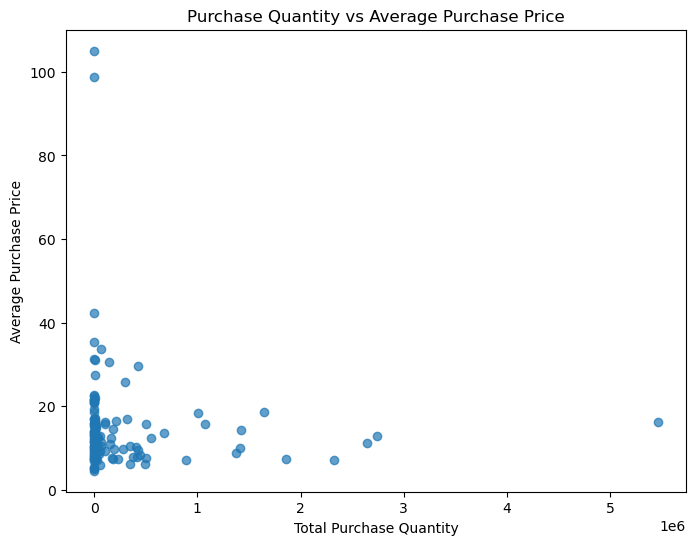

In [18]:
#Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    vendor_purchase['Total_Quantity'],
    vendor_purchase['Avg_PurchasePrice'],
    alpha=0.7
)

plt.xlabel("Total Purchase Quantity")
plt.ylabel("Average Purchase Price")
plt.title("Purchase Quantity vs Average Purchase Price")

plt.show()

# **Business Insight:**

- The correlation analysis reveals a very weak negative relationship between total purchase quantity and average purchase price (r = -0.072). Furthermore, the relationship is not statistically significant (p = 0.422).

- These findings suggest that vendors supplying larger purchase volumes do not consistently provide lower purchase prices. Therefore, procurement costs appear to be influenced by factors other than purchase quantity, such as vendor-specific pricing agreements, product mix, brand characteristics, or negotiated contracts.

# **Correlation Between Sales and Profit**

# **Business Objective:**

- **Determine whether increasing sales leads to proportional increases in profitability.**

In [21]:
# Vendor Dataset
vendor_sales = (
    sales
    .groupby(['VendorNo', 'VendorName'], as_index=False)
    .agg(
        Total_Sales=('SalesDollars', 'sum'),
        Total_Profit=('SalesPrice', lambda x: 0) 
    )
)

In [22]:
#Total Profit
vendor_profit = pd.read_sql(
    text("""
       SELECT
s.VendorNo,
s.VendorName,
SUM(s.SalesDollars) AS TotalSales,
SUM(s.SalesQuantity * p.PurchasePrice) AS TotalCost,
ROUND(SUM(s.SalesDollars - (s.SalesQuantity * p.PurchasePrice)),2) AS TotalProfit
FROM sales s
JOIN purchase_prices p
ON s.Brand = p.Brand
AND s.Description = p.Description
AND s.Size = p.Size
GROUP BY
s.VendorNo,
s.VendorName;
    """),
    engine
)

In [23]:
#Pearson Correlation Coefficient
corr, p_value = pearsonr(
    vendor_profit["TotalSales"],
    vendor_profit["TotalProfit"]
)

print(f"Correlation : {corr:.3f}")
print(f"P-value     : {p_value:.5f}")

Correlation : 0.990
P-value     : 0.00000


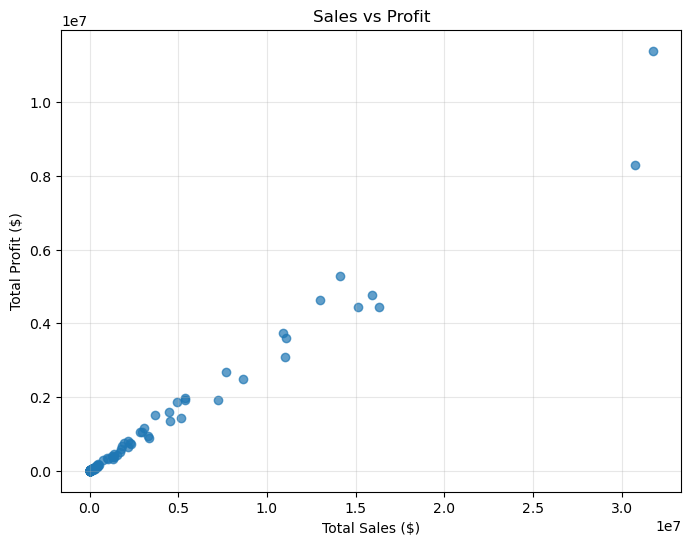

In [48]:
# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    vendor_profit['TotalSales'],
    vendor_profit['TotalProfit'],
    alpha=0.7
)

plt.title("Sales vs Profit")
plt.xlabel("Total Sales ($)")
plt.ylabel("Total Profit ($)")

plt.grid(alpha=0.3)

plt.show()

# **Business Insight:**

- The correlation analysis reveals an extremely strong positive relationship (r = 0.990) between total sales and total profit across vendors.

- This indicates that vendors contributing higher revenue generally generate proportionally higher profits. The statistical significance (p < 0.001) confirms that this relationship is highly unlikely to have occurred by chance.

- These findings suggest that increasing sales from high-performing vendors can directly contribute to improving overall business profitability.

# **Correlation Between Purchase Price and Sales Price**


# **Business Objective:**

- **Determine whether products with higher procurement costs are also sold at higher prices.**

In [25]:
# Product Dataset
product_price = (
    sales.groupby(['Brand', 'Description', 'Size'], as_index=False)
    .agg(
        Avg_SalesPrice=('SalesPrice', 'mean')
    )
)

purchase_price = (
    purchase_prices.groupby(['Brand', 'Description', 'Size'], as_index=False)
    .agg(
        Avg_PurchasePrice=('PurchasePrice', 'mean')
    )
)

In [26]:
# Merge
price_analysis = product_price.merge(
    purchase_price,
    on=['Brand', 'Description', 'Size'],
    how='inner'
)

price_analysis.head()

,Brand,Description,Size,Avg_SalesPrice,Avg_PurchasePrice
0,58,Gekkeikan Black & Gold Sake,750mL,12.587496,9.28
1,60,Canadian Club 1858 VAP,750mL,10.500284,7.40
2,61,Margaritaville Silver,750mL,13.990000,10.60
3,62,Herradura Silver Tequila,750mL,38.379953,28.67
4,63,Herradura Reposado Tequila,750mL,40.435205,30.46


In [27]:
# shape
price_analysis.shape

(9786, 5)

In [28]:
#Pearson Correlation Coefficient
corr, p_value = pearsonr(
    price_analysis['Avg_PurchasePrice'],
    price_analysis['Avg_SalesPrice']
)

print(f"Correlation : {corr:.3f}")
print(f"P-value     : {p_value:.5f}")

Correlation : 0.998
P-value     : 0.00000


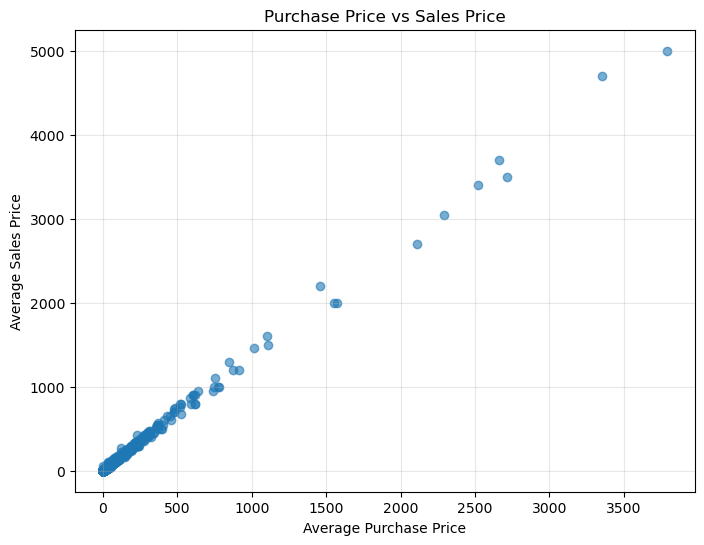

In [31]:
#Scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    price_analysis['Avg_PurchasePrice'],
    price_analysis['Avg_SalesPrice'],
    alpha=0.6
)

plt.xlabel("Average Purchase Price")
plt.ylabel("Average Sales Price")
plt.title("Purchase Price vs Sales Price")

plt.grid(alpha=0.3)

plt.show()

# **Business Insight:**

- The analysis reveals an almost perfect positive correlation (r = 0.998) between purchase price and sales price. This indicates that the company consistently adjusts its selling prices based on procurement costs.

- The statistically significant relationship (p < 0.001) suggests that the organization's pricing strategy effectively reflects changes in vendor pricing, helping preserve overall profitability.

# **Correlation Between Inventory On-Hand and Sales Quantity**


# **Business Objective:**

- **Evaluate whether maintaining higher inventory levels leads to increased sales.**

In [32]:
#Product Inventory
inventory_summary = (
    end_inventory
    .groupby(['Brand', 'Description', 'Size'], as_index=False)
    .agg(
        Inventory_OnHand=('onHand', 'sum')
    )
)

inventory_summary.head()

,Brand,Description,Size,Inventory_OnHand
0,58,Gekkeikan Black & Gold Sake,750mL,385
1,60,Canadian Club 1858 VAP,750mL,146
2,61,Margaritaville Silver,750mL,12
3,62,Herradura Silver Tequila,750mL,459
4,63,Herradura Reposado Tequila,750mL,442


In [34]:
#Product Sales
sales_summary = (
    sales
    .groupby(['Brand', 'Description', 'Size'], as_index=False)
    .agg(
        Total_SalesQty=('SalesQuantity', 'sum')
    )
)

sales_summary.head()

,Brand,Description,Size,Total_SalesQty
0,58,Gekkeikan Black & Gold Sake,750mL,3446
1,60,Canadian Club 1858 VAP,750mL,1775
2,61,Margaritaville Silver,750mL,312
3,62,Herradura Silver Tequila,750mL,3125
4,63,Herradura Reposado Tequila,750mL,2778


In [35]:
# Merge
inventory_sales = inventory_summary.merge(
    sales_summary,
    on=['Brand', 'Description', 'Size'],
    how='inner'
)

inventory_sales.head()

,Brand,Description,Size,Inventory_OnHand,Total_SalesQty
0,58,Gekkeikan Black & Gold Sake,750mL,385,3446
1,60,Canadian Club 1858 VAP,750mL,146,1775
2,61,Margaritaville Silver,750mL,12,312
3,62,Herradura Silver Tequila,750mL,459,3125
4,63,Herradura Reposado Tequila,750mL,442,2778


In [37]:
#shape
inventory_sales.shape

(9139, 5)

In [38]:
corr, p_value = pearsonr(
    inventory_sales['Inventory_OnHand'],
    inventory_sales['Total_SalesQty']
)

print(f"Correlation : {corr:.3f}")
print(f"P-value     : {p_value:.5f}")

Correlation : 0.844
P-value     : 0.00000


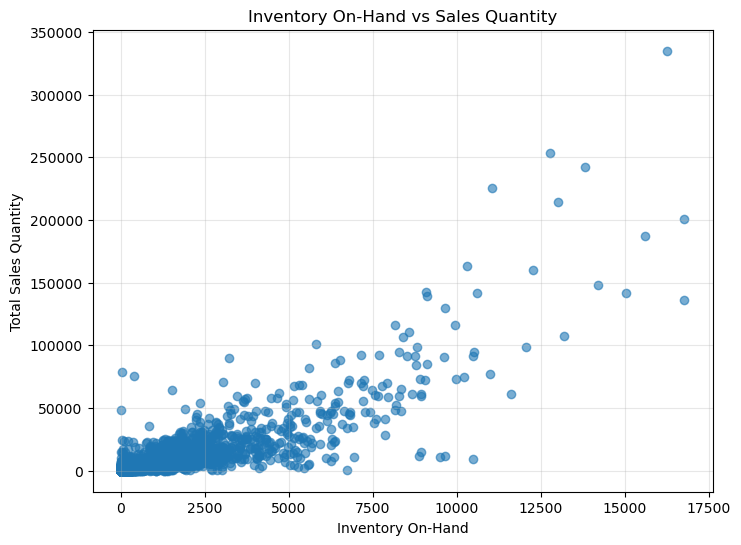

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    inventory_sales['Inventory_OnHand'],
    inventory_sales['Total_SalesQty'],
    alpha=0.6
)

plt.xlabel("Inventory On-Hand")
plt.ylabel("Total Sales Quantity")
plt.title("Inventory On-Hand vs Sales Quantity")

plt.grid(alpha=0.3)

plt.show()

# **Business Insight:**

- The analysis reveals a strong positive correlation (r = 0.844) between inventory on-hand and sales quantity. Products with greater inventory availability tend to generate higher sales volumes.

- The statistically significant relationship indicates that inventory planning is reasonably aligned with customer demand. Products experiencing strong demand are generally stocked at higher levels, reducing the likelihood of stockouts and supporting consistent sales performance.

- However, since the correlation is not perfect (1.0), inventory level alone does not fully explain sales performance. Other factors such as pricing, promotions, seasonality, and customer preferences also influence product demand.

# **Correlation Matrix**

# **Business Objective:**

- **Understand the relationships among key business metrics involved in purchasing, sales, inventory, and pricing.**

In [40]:
# Analysis Dataset
analysis_df = (
    sales
    .groupby(['Brand', 'Description', 'Size'], as_index=False)
    .agg(
        SalesQuantity=('SalesQuantity', 'sum'),
        SalesDollars=('SalesDollars', 'sum'),
        AvgSalesPrice=('SalesPrice', 'mean')
    )
)

purchase_df = (
    purchase_prices
    .groupby(['Brand', 'Description', 'Size'], as_index=False)
    .agg(
        AvgPurchasePrice=('PurchasePrice', 'mean')
    )
)

inventory_df = (
    end_inventory
    .groupby(['Brand', 'Description', 'Size'], as_index=False)
    .agg(
        InventoryOnHand=('onHand', 'sum')
    )
)

analysis_df = (
    analysis_df
    .merge(purchase_df, on=['Brand','Description','Size'])
    .merge(inventory_df, on=['Brand','Description','Size'])
)

analysis_df.head()

,Brand,Description,Size,SalesQuantity,SalesDollars,AvgSalesPrice,AvgPurchasePrice,InventoryOnHand
0,58,Gekkeikan Black & Gold Sake,750mL,3446,43341.54,12.587496,9.28,385
1,60,Canadian Club 1858 VAP,750mL,1775,18716.25,10.500284,7.40,146
2,61,Margaritaville Silver,750mL,312,4364.88,13.990000,10.60,12
3,62,Herradura Silver Tequila,750mL,3125,119863.75,38.379953,28.67,459
4,63,Herradura Reposado Tequila,750mL,2778,112249.22,40.435205,30.46,442


In [42]:
# Calculate Profit
analysis_df["Profit"] = (
    analysis_df["SalesDollars"]
    - (analysis_df["SalesQuantity"] * analysis_df["AvgPurchasePrice"])
)

In [43]:
# Calculate Profit Margin
analysis_df["ProfitMargin"] = (
    analysis_df["Profit"]
    / analysis_df["SalesDollars"]
) * 100

In [44]:
#Correlation Matrix
corr_matrix = analysis_df[
    [
        "SalesQuantity",
        "SalesDollars",
        "AvgSalesPrice",
        "AvgPurchasePrice",
        "InventoryOnHand",
        "Profit",
        "ProfitMargin"
    ]
].corr(method="pearson")

corr_matrix

,SalesQuantity,SalesDollars,AvgSalesPrice,AvgPurchasePrice,InventoryOnHand,Profit,ProfitMargin
SalesQuantity,1.000000,0.570258,-0.054715,-0.052223,0.808463,0.570367,-0.030962
SalesDollars,0.570258,1.000000,-0.026798,-0.025225,0.583214,0.977796,-0.013795
AvgSalesPrice,-0.054715,-0.026798,1.000000,0.997998,-0.075134,-0.029866,-0.037970
AvgPurchasePrice,-0.052223,-0.025225,0.997998,1.000000,-0.071872,-0.029643,-0.057043
InventoryOnHand,0.808463,0.583214,-0.075134,-0.071872,1.000000,0.591728,-0.027183
Profit,0.570367,0.977796,-0.029866,-0.029643,0.591728,1.000000,0.063165
ProfitMargin,-0.030962,-0.013795,-0.037970,-0.057043,-0.027183,0.063165,1.000000


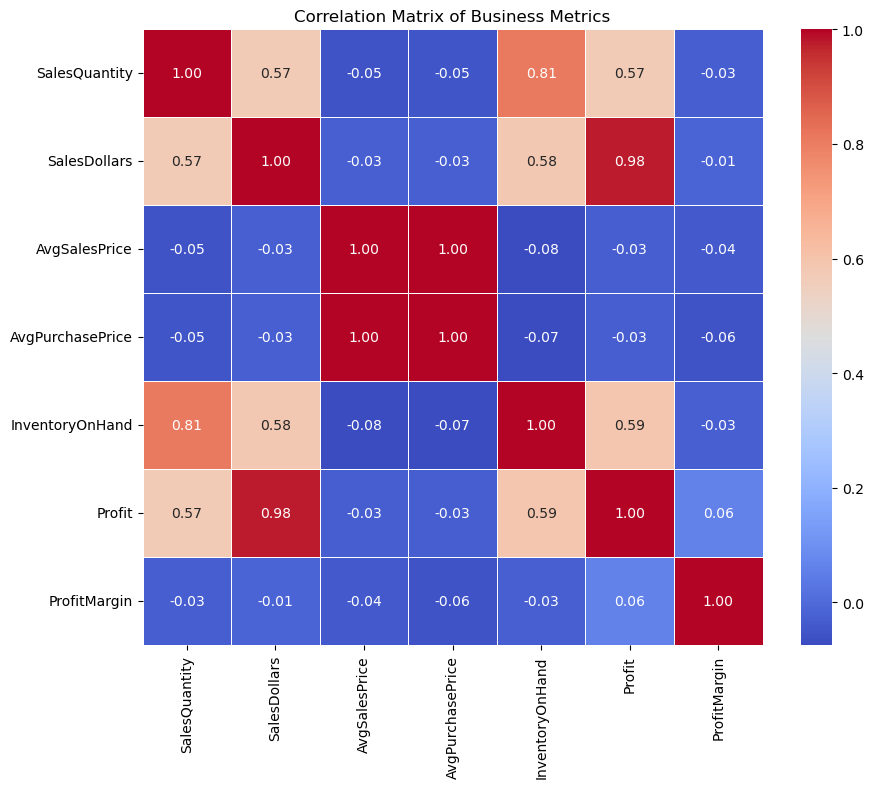

In [150]:
#Correlation Matrix plot
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Business Metrics")

plt.show()

# **Correlation Matrix – Key Findings**

# **1. Purchase Price and Sales Price**

**Correlation:** **0.998** (Very Strong Positive)

**Business Insight:**

- Purchase price and sales price exhibit an almost perfect positive correlation, indicating that increases in procurement costs are consistently reflected in product selling prices. This demonstrates that the company's pricing strategy effectively incorporates changes in supplier costs, helping maintain profit margins.

**Business Recommendation:**

- Continue monitoring procurement costs and implement periodic pricing reviews to ensure selling prices remain aligned with supplier price changes.

# **2. Sales and Profit**

**Correlation:** **0.990** (Very Strong Positive)

**Business Insight:**

- A very strong positive relationship exists between total sales and profit, suggesting that vendors generating higher revenue also contribute significantly to overall profitability.

- However, since profit is calculated using sales revenue, this relationship is expected and primarily validates the profit calculation methodology.

**Business Recommendation:**

- Focus on increasing sales through profitable vendors while monitoring products with strong sales but lower profit margins.

# **3. Inventory On-Hand and Sales Quantity**

**Correlation: 0.844** (Strong Positive)

**Business Insight:**

- Products maintained at higher inventory levels generally experience higher sales quantities. This indicates that inventory planning is largely aligned with customer demand and helps minimize stock shortages.

**Business Recommendation:**

- Continue using historical demand to guide inventory planning while identifying products with high inventory but relatively low sales for potential stock optimization.

# **4. Purchase Quantity and Purchase Price**

**Correlation: -0.072** (Very Weak Negative)

**Business Insight:**

- Purchase quantity has almost no meaningful relationship with purchase price. Larger purchase volumes do not consistently result in lower procurement costs across vendors.

**Business Recommendation:**

- Procurement strategies should prioritize vendor negotiations, contract terms, and supplier evaluation rather than assuming bulk purchasing alone will reduce costs.

# **2: DISTRIBUTION ANALYSIS**

# **Revenue Distribution**

**Business Objective:**

- **Evaluate how revenue is distributed across vendors to determine whether the business depends heavily on a small number of suppliers.**

In [49]:
# Vendor Revenue Dataset
vendor_revenue = (
    sales
    .groupby(["VendorNo", "VendorName"], as_index=False)
    .agg(
        TotalRevenue=("SalesDollars", "sum")
    )
)

vendor_revenue.head()

,VendorNo,VendorName,TotalRevenue
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",1265.58
1,60,ADAMBA IMPORTS INTL INC,67576.22
2,105,ALTAMAR BRANDS LLC,15748.75
3,200,AMERICAN SPIRITS EXCHANGE,1719.97
4,287,APPOLO VINEYARDS LLC,1616.92


In [50]:
# Descriptive Statistics
vendor_revenue["TotalRevenue"].describe()

count    1.290000e+02
mean     3.504364e+06
std      8.994677e+06
min      1.499000e+01
25%      3.504963e+04
50%      1.495649e+05
75%      2.586254e+06
max      6.874242e+07
Name: TotalRevenue, dtype: float64

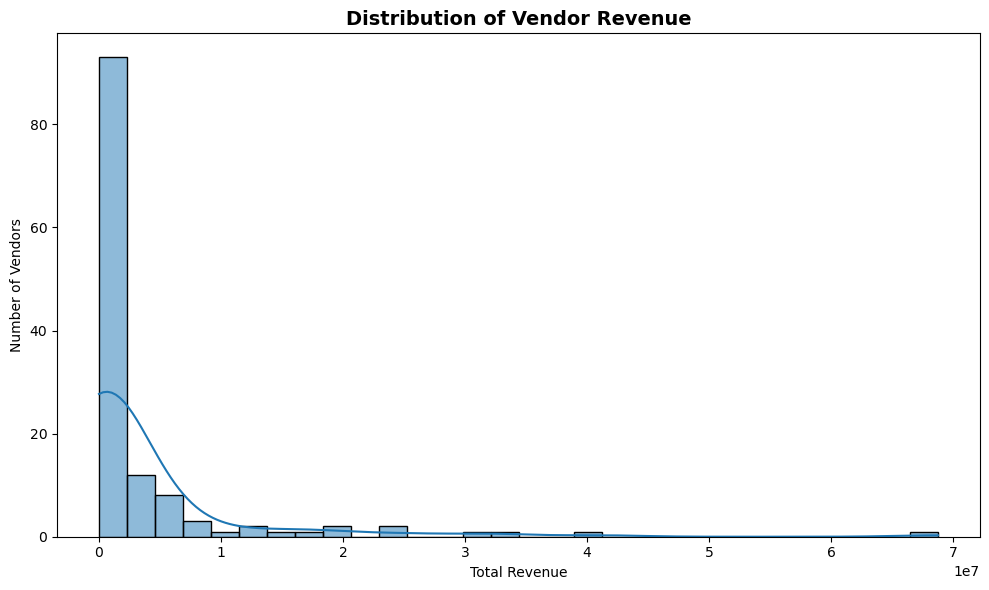

In [62]:
# Histogram + KDE
plt.figure(figsize=(10,6))

sns.histplot(
    data=vendor_revenue,
    x="TotalRevenue",
    bins=30,
    kde=True
)

plt.title("Distribution of Vendor Revenue", fontsize=14, weight="bold")
plt.xlabel("Total Revenue")
plt.ylabel("Number of Vendors")

plt.tight_layout()
plt.show()

In [52]:
#Mean, Median & Skewness
mean = vendor_revenue["TotalRevenue"].mean()
median = vendor_revenue["TotalRevenue"].median()
skewness = vendor_revenue["TotalRevenue"].skew()

print(f"Mean Revenue   : {mean:,.2f}")
print(f"Median Revenue : {median:,.2f}")
print(f"Skewness       : {skewness:.3f}")

Mean Revenue   : 3,504,363.97
Median Revenue : 149,564.94
Skewness       : 4.439


In [54]:
# Nornmality Test
n = len(vendor_revenue)

print(f"Number of Vendors: {n}")

Number of Vendors: 129


In [56]:
# n<=5000
stat, p = shapiro(vendor_revenue["TotalRevenue"])

print(f"Statistic : {stat:.4f}")
print(f"P-value   : {p:.5f}")

Statistic : 0.4375
P-value   : 0.00000


# **Business Insight:**

- Vendor revenue is highly concentrated among a small number of suppliers. The substantial difference between the mean and median revenue, combined with a skewness of **4.439**, indicates that only a few vendors contribute the majority of the company's revenue.

- The non-normal distribution suggests that revenue generation is heavily influenced by a limited number of strategic vendors rather than being evenly spread across the supplier base.

- This concentration increases operational risk, as the loss of one or more high-performing vendors could significantly impact overall business revenue.

- Revenue distribution is highly right-skewed (Skewness = 4.439).

- Mean revenue is significantly higher than the median, confirming strong revenue concentration.

- Revenue is not normally distributed (Shapiro-Wilk p < 0.001).

- A small number of vendors generate a disproportionately large share of total revenue.

- The business faces supplier concentration risk and should pursue revenue diversification strategies.

# **Profit Distribution**

**Business Objective:**

- **Analyze the distribution of vendor profits to determine whether profitability is evenly distributed or concentrated among a small number of vendors.**

In [58]:
#Vendor Profit Dataset
vendor_profit.head()

,VendorNo,VendorName,TotalSales,TotalCost,TotalProfit
0,60,ADAMBA IMPORTS INTL INC,704.53,537.68,166.85
1,1703,ALISA CARR BEVERAGES,118167.38,77786.48,40380.90
2,105,ALTAMAR BRANDS LLC,15748.75,11273.77,4474.98
3,200,AMERICAN SPIRITS EXCHANGE,1719.97,960.39,759.58
4,287,APPOLO VINEYARDS LLC,1616.92,1127.40,489.52


In [60]:
# Descriptive Statistics
vendor_profit["TotalProfit"].describe()

count    1.250000e+02
mean     7.097622e+05
std      1.634203e+06
min      4.120000e+00
25%      9.520670e+03
50%      4.093114e+04
75%      5.786327e+05
max      1.139809e+07
Name: TotalProfit, dtype: float64

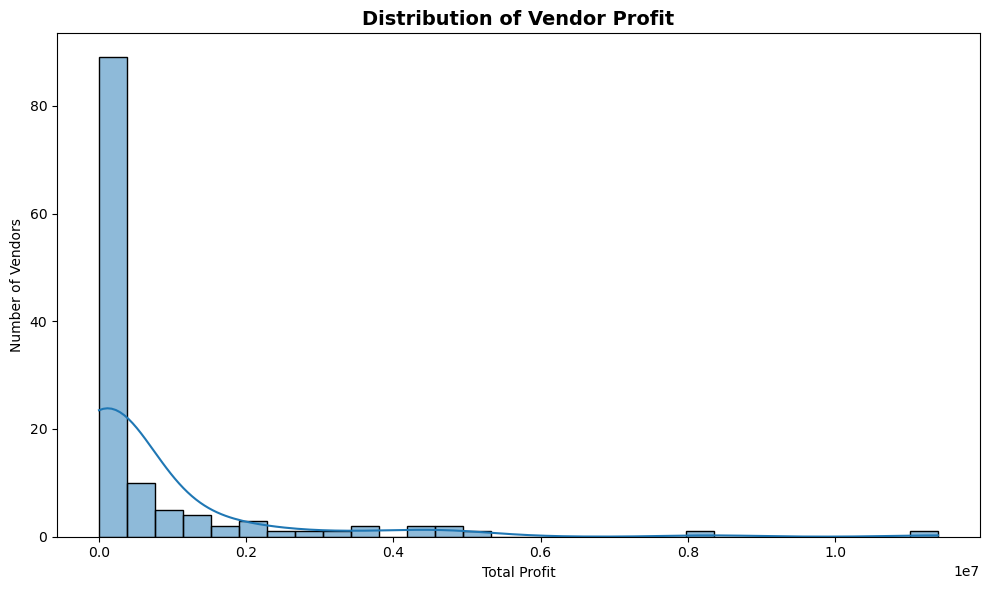

In [63]:
# Histogram + KDE
plt.figure(figsize=(10,6))

sns.histplot(
    data=vendor_profit,
    x="TotalProfit",
    bins=30,
    kde=True
)

plt.title("Distribution of Vendor Profit", fontsize=14, weight="bold")
plt.xlabel("Total Profit")
plt.ylabel("Number of Vendors")

plt.tight_layout()

plt.show()

In [64]:
# Mean, Median & Skewness
mean = vendor_profit["TotalProfit"].mean()
median = vendor_profit["TotalProfit"].median()
skewness = vendor_profit["TotalProfit"].skew()

print(f"Mean Profit   : {mean:,.2f}")
print(f"Median Profit : {median:,.2f}")
print(f"Skewness      : {skewness:.3f}")

Mean Profit   : 709,762.18
Median Profit : 40,931.14
Skewness      : 3.844


In [79]:
# Nornmality Test
n = len(vendor_revenue)

print(f"Number of Vendors: {n}")

Number of Vendors: 129


In [65]:
# n<=5000
stat, p = shapiro(vendor_profit["TotalProfit"])

print(f"Statistic : {stat:.4f}")
print(f"P-value   : {p:.5f}")

Statistic : 0.4907
P-value   : 0.00000


# **Business Insight:**

- Vendor profitability is highly concentrated among a limited number of suppliers. Although the average vendor profit exceeds **709,000** , the median profit is only **40,931** , indicating that a few highly profitable vendors substantially increase the overall average.

- The strong positive skewness **3.844** and the non-normal distribution confirm that business profitability depends heavily on a relatively small group of vendors rather than being evenly distributed across the supplier base.

-  Profit distribution is highly right-skewed (Skewness = 3.844).

- Average profit is substantially higher than the median, confirming strong profit concentration.

- Profit is not normally distributed (Shapiro-Wilk p < 0.001).

- A small number of vendors generate a disproportionately large share of total business profit.

- Management should improve profitability across mid-performing vendors to reduce dependency on a few high-profit suppliers.

# **Profit Margin Distribution**

**Business Objective:**

- **Evaluate the distribution of vendor profit margins to determine whether profitability is consistent across vendors.**

In [66]:
# calculate Profit Margin
vendor_profit["ProfitMargin"] = (
    vendor_profit["TotalProfit"] /
    vendor_profit["TotalSales"]
) * 100

In [67]:
# Descriptive Statistics
vendor_profit["ProfitMargin"].describe()

count    125.000000
mean      30.550679
std        6.311569
min       10.675778
25%       27.165521
50%       32.180221
75%       34.585541
max       44.162398
Name: ProfitMargin, dtype: float64

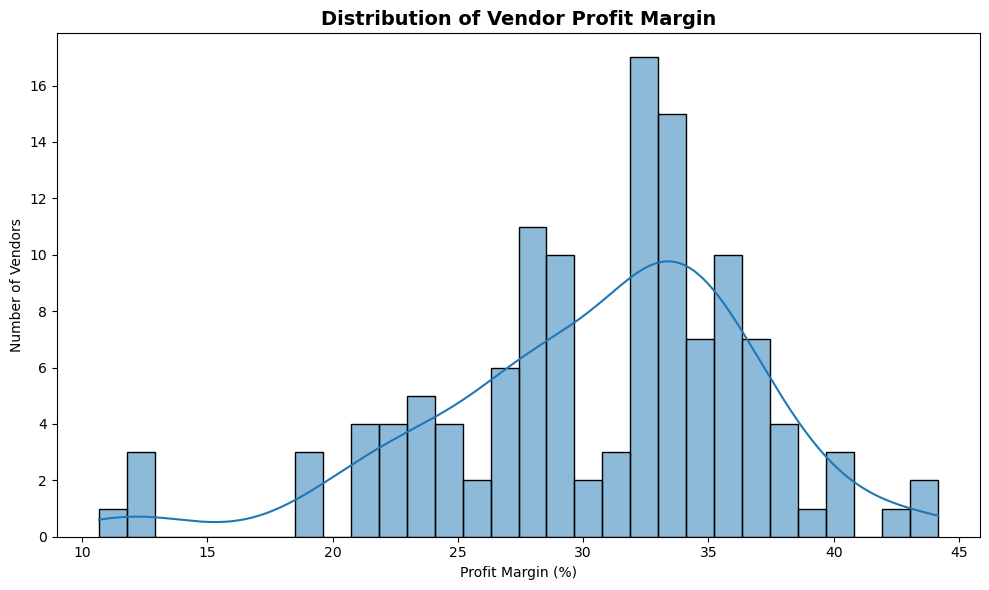

In [68]:
# Histogram + KDE
plt.figure(figsize=(10,6))

sns.histplot(
    data=vendor_profit,
    x="ProfitMargin",
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Vendor Profit Margin",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Profit Margin (%)")
plt.ylabel("Number of Vendors")

plt.tight_layout()

plt.show()

In [69]:
# Mean, Median & Skewness
mean = vendor_profit["ProfitMargin"].mean()
median = vendor_profit["ProfitMargin"].median()
skewness = vendor_profit["ProfitMargin"].skew()

print(f"Mean Profit Margin   : {mean:.2f}%")
print(f"Median Profit Margin : {median:.2f}%")
print(f"Skewness             : {skewness:.3f}")

Mean Profit Margin   : 30.55%
Median Profit Margin : 32.18%
Skewness             : -0.749


In [80]:
# Nornmality Test
n = len(vendor_revenue)

print(f"Number of Vendors: {n}")

Number of Vendors: 129


In [81]:
# n<=5000
stat, p = shapiro(vendor_profit["ProfitMargin"])

print(f"Statistic : {stat:.4f}")
print(f"P-value   : {p:.5f}")

Statistic : 0.9580
P-value   : 0.00066


# **Business Insight:**

- Unlike revenue and profit, vendor profit margins exhibit a relatively consistent distribution. Most vendors operate within a profit margin range of approximately **30%** to **35%**, indicating that the company's pricing strategy is generally consistent across suppliers.

- The moderate left skew suggests that a small number of vendors operate with unusually low margins, reducing the overall average profit margin.

- These vendors may represent opportunities for pricing optimization, procurement cost reduction, or contract renegotiation.

- Average vendor profit margin is **30.55%**.

- Most vendors operate between **30%–35%** margins.

- Profit margin is moderately left-skewed (Skewness = -0.749).

- Only a small number of vendors exhibit unusually low margins.

- Margin optimization should focus on these low-margin vendors rather than changing pricing across the entire supplier base.

# **Inventory Value Distribution**

**Business Objective:**

- **Analyze how inventory investment is distributed across products to identify capital concentration and inventory risk.**

In [72]:
# Inventory Value
inventory_value = (
    end_inventory
    .groupby(["Brand", "Description", "Size"], as_index=False)
    .agg(
        Inventory_OnHand=("onHand", "sum"),
        UnitPrice=("Price", "mean")
    )
)

inventory_value["InventoryValue"] = (
    inventory_value["Inventory_OnHand"] *
    inventory_value["UnitPrice"]
)

inventory_value.head()

,Brand,Description,Size,Inventory_OnHand,UnitPrice,InventoryValue
0,58,Gekkeikan Black & Gold Sake,750mL,385,12.99,5001.15
1,60,Canadian Club 1858 VAP,750mL,146,10.99,1604.54
2,61,Margaritaville Silver,750mL,12,13.99,167.88
3,62,Herradura Silver Tequila,750mL,459,36.99,16978.41
4,63,Herradura Reposado Tequila,750mL,442,38.99,17233.58


In [73]:
# Descriptive Statistics
inventory_value["InventoryValue"].describe()

count      9653.000000
mean       8257.003121
std       21187.453021
min           0.000000
25%         349.670000
50%        2479.690000
75%        8399.970000
max      526494.530000
Name: InventoryValue, dtype: float64

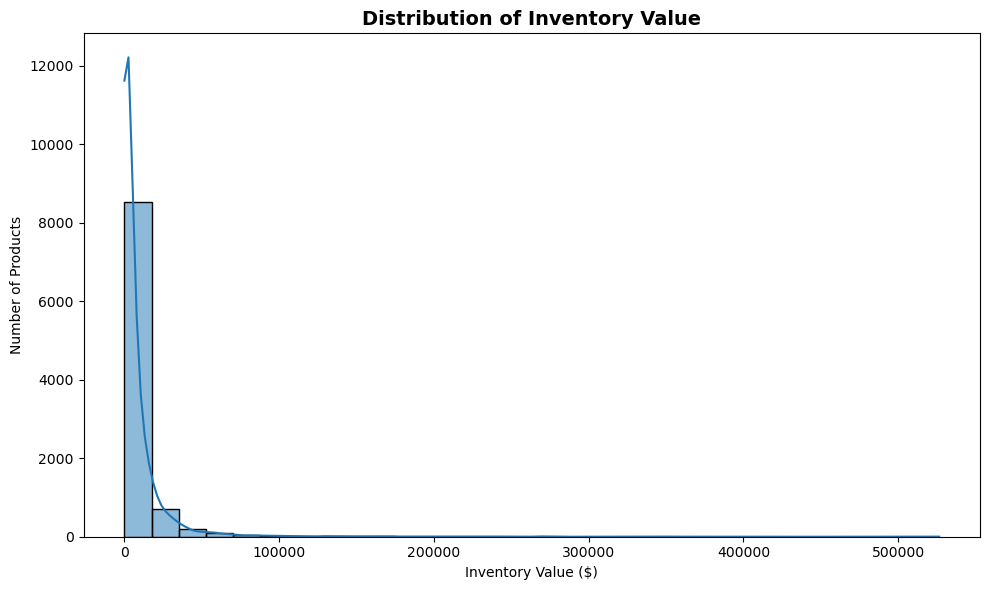

In [74]:
# Histogram + KDE
plt.figure(figsize=(10,6))

sns.histplot(
    data=inventory_value,
    x="InventoryValue",
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Inventory Value",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Inventory Value ($)")
plt.ylabel("Number of Products")

plt.tight_layout()

plt.show()

In [86]:
# Mean, Median & Skewness
mean = inventory_value["InventoryValue"].mean()
median = inventory_value["InventoryValue"].median()
skewness = inventory_value["InventoryValue"].skew()

print(f"Mean Inventory Value   : {mean:,.2f}")
print(f"Median Inventory Value : {median:,.2f}")
print(f"Skewness               : {skewness:.3f}")

Mean Inventory Value   : 8,257.00
Median Inventory Value : 2,479.69
Skewness               : 10.046


In [87]:
# Nornmality Test
n = len(vendor_revenue)

print(f"Number of Vendors: {n}")

Number of Vendors: 129


In [90]:
# n<=5000
stat, p = normaltest(inventory_value["InventoryValue"])

print(f"Statistic : {stat:.4f}")
print(f"P-value   : {p:.5f}")

Statistic : 15167.4767
P-value   : 0.00000


# **Business Insight:**

- Inventory investment is highly concentrated among a relatively small number of products. Although the average inventory value exceeds **8,257**, the median value is only **2,480**, indicating that a limited number of products account for a disproportionately large share of the company's inventory investment.

- The extremely high positive skewness **10.046** confirms that working capital is concentrated in a small subset of inventory items.

- This concentration increases inventory carrying costs and exposes the business to greater financial risk if demand for these high-value products declines.

- Mean inventory value is $8,257, while the median is only $2,480.

- Inventory value exhibits extreme positive skewness (10.046).

- A small number of products account for a large proportion of inventory investment.

- Inventory is not normally distributed.

- High-value inventory items should receive priority in inventory planning and demand forecasting.

# **Distribution Analysis Summary**

| Business Metric     | Distribution           | Key Statistical Finding | Business Insight                                                    | Recommendation                                                |
| ------------------- | ---------------------- | ----------------------- | ------------------------------------------------------------------- | ------------------------------------------------------------- |
| **Revenue**         | Highly Right-Skewed    | Skewness = **4.439**    | Revenue is concentrated among a few vendors.                        | Diversify vendor portfolio to reduce dependency.              |
| **Profit**          | Highly Right-Skewed    | Skewness = **3.844**    | Profitability depends heavily on a limited number of vendors.       | Improve profitability of mid-performing vendors.              |
| **Profit Margin**   | Moderately Left-Skewed | Skewness = **-0.749**   | Most vendors maintain consistent margins, while a few underperform. | Review vendors with unusually low profit margins.             |
| **Inventory Value** | Extremely Right-Skewed | Skewness = **10.046**   | Working capital is concentrated in a small number of products.      | Optimize inventory investment and improve inventory turnover. |


# **3: OUTLIER ANALYSIS**

# **High Inventory Value Products**

**Business Objective:**

- **Identify products that tie up a disproportionately large amount of working capital.**

In [92]:
# Calculate IQR
Q1 = inventory_value["InventoryValue"].quantile(0.25)
Q3 = inventory_value["InventoryValue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound : {lower_bound:.2f}")
print(f"Upper Bound : {upper_bound:.2f}")

Lower Bound : -11725.78
Upper Bound : 20475.42


In [93]:
# Detect Outliers
inventory_outliers = inventory_value[
    inventory_value["InventoryValue"] > upper_bound
]

inventory_outliers.head()

,Brand,Description,Size,Inventory_OnHand,UnitPrice,InventoryValue
7,77,Three Olives Espresso Vodka,750mL,1764,14.99,26442.36
23,115,Belvedere Vodka,Liter,1526,27.99,42712.74
26,126,Grey Goose Vodka,Liter,4464,29.99,133875.36
40,171,Gentleman Jack,1.75L,965,49.99,48240.35
77,273,Sauza Extra Gold Tequila,1.75L,4052,21.99,89103.48


In [94]:
# Number of Outliers
print(f"Total Outliers : {len(inventory_outliers)}")

Total Outliers : 901


In [95]:
# Percentage of Outliers
percentage = (
    len(inventory_outliers) /
    len(inventory_value)
) * 100

print(f"Percentage of Outliers : {percentage:.2f}%")

Percentage of Outliers : 9.33%


In [98]:
# Total Inventory Value of Outliers
outlier_inventory_value = inventory_outliers["InventoryValue"].sum()

print(f"Total Inventory Value (Outliers): ${outlier_inventory_value:,.2f}")

Total Inventory Value (Outliers): $44,852,701.26


In [99]:
# Percentage of Total Inventory Investment
total_inventory_value = inventory_value["InventoryValue"].sum()

percentage_value = (
    outlier_inventory_value /
    total_inventory_value
) * 100

print(f"Percentage of Total Inventory Investment: {percentage_value:.2f}%")

Percentage of Total Inventory Investment: 56.27%


In [100]:
# Top 10 Highest Inventory Value Products
top_inventory_brands = (
    inventory_outliers
    .groupby("Brand")
    .agg(
        Products=("Brand", "count"),
        TotalInventoryValue=("InventoryValue", "sum")
    )
    .sort_values(
        by="TotalInventoryValue",
        ascending=False
    )
)

top_inventory_brands.head(10)

,Products,TotalInventoryValue
Brand,,
1233,1,526494.53
3545,1,502932.30
2753,1,470861.51
8068,1,366631.92
3405,1,355649.32
4261,1,351981.31
2757,1,336370.97
2589,1,300956.78
1376,1,276648.20


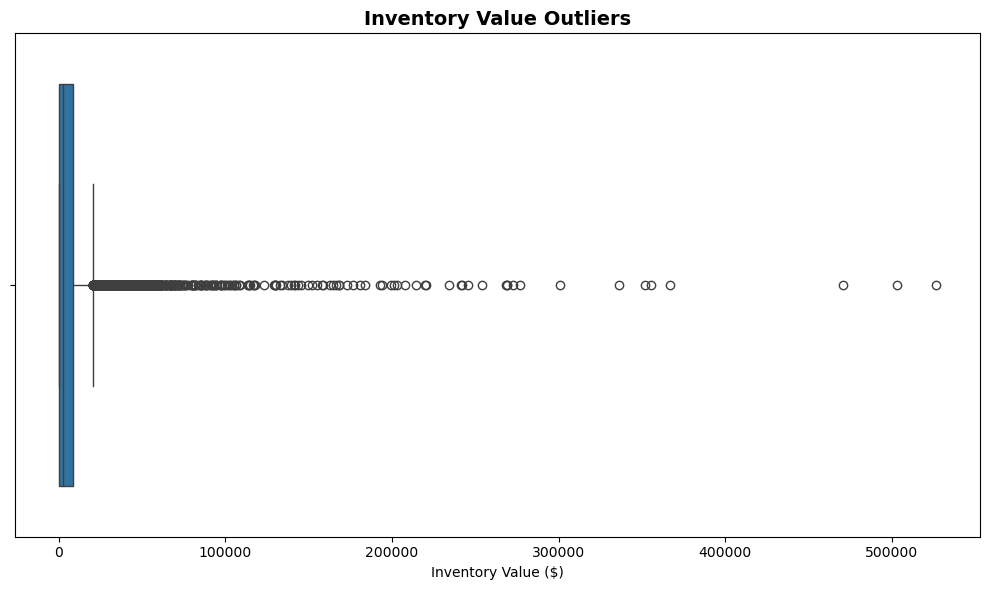

In [101]:
# Box Plot
plt.figure(figsize=(10,6))

sns.boxplot(
    x=inventory_value["InventoryValue"]
)

plt.title(
    "Inventory Value Outliers",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Inventory Value ($)")

plt.tight_layout()

plt.show()

# **Outlier Summary**

| Metric                               |                       Value |
| ------------------------------------ | --------------------------: |
| Products Analyzed                    |                   **9,653** |
| Outliers Detected                    |             **901** (9.33%) |
| Inventory Investment Represented     |          **44,852,701.26**  |
| Highest Inventory Product            | **Jack Daniels No.7 Black** |
| Highest Inventory Value              |             **526,494.53**  |


# **Business Insight:**

- The analysis reveals that **901** products (9.33% of the inventory portfolio) have unusually high inventory values. These products tie up a significant amount of the company's working capital and therefore require closer monitoring.

- Several premium spirits, including Jack Daniel's No. 7 Black, Ketel One Vodka, Johnnie Walker Black Label, Absolut 80 Proof, and Tito's Handmade Vodka, appear among the highest-value inventory items. This suggests that inventory investment is concentrated in premium liquor brands with high demand and/or high unit prices.

- While these products may be strong sellers, maintaining excessive inventory levels increases carrying costs, storage requirements, and the financial risk associated with slower-than-expected demand.

# **Low Profit Margin Vendors**

**Business Objective:**

- **Identify vendors operating with unusually low profit margins to improve pricing strategy and procurement efficiency.**

In [102]:
# Calculate IQR
Q1 = vendor_profit["ProfitMargin"].quantile(0.25)
Q3 = vendor_profit["ProfitMargin"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound : {lower_bound:.2f}%")
print(f"Upper Bound : {upper_bound:.2f}%")

Lower Bound : 16.04%
Upper Bound : 45.72%


In [103]:
# Detect Low Profit Margin Vendors
low_margin_vendors = vendor_profit[
    vendor_profit["ProfitMargin"] < lower_bound
]

low_margin_vendors

,VendorNo,VendorName,TotalSales,TotalCost,TotalProfit,ProfitMargin
44,3950,"HOOD RIVER DISTILLERS, Inc.",29403.29,26264.26,3139.03,10.675778
52,4848,LAIRD & CO,195413.91,170649.06,24764.85,12.673023
93,8663,STAR INDUSTRIES INC.,7770.86,6793.74,977.12,12.574155
113,9751,VINEDREA WINES LLC,11385.60,9996.80,1388.80,12.197864


In [104]:
# Number of Vendors
print(f"Low Margin Vendors : {len(low_margin_vendors)}")

Low Margin Vendors : 4


In [105]:
# Percentage
percentage = (
    len(low_margin_vendors) /
    len(vendor_profit)
) * 100

print(f"Percentage : {percentage:.2f}%")

Percentage : 3.20%


In [106]:
# Worst Vendors
low_margin_vendors.sort_values(
    by="ProfitMargin"
).head(10)

,VendorNo,VendorName,TotalSales,TotalCost,TotalProfit,ProfitMargin
44,3950,"HOOD RIVER DISTILLERS, Inc.",29403.29,26264.26,3139.03,10.675778
113,9751,VINEDREA WINES LLC,11385.60,9996.80,1388.80,12.197864
93,8663,STAR INDUSTRIES INC.,7770.86,6793.74,977.12,12.574155
52,4848,LAIRD & CO,195413.91,170649.06,24764.85,12.673023


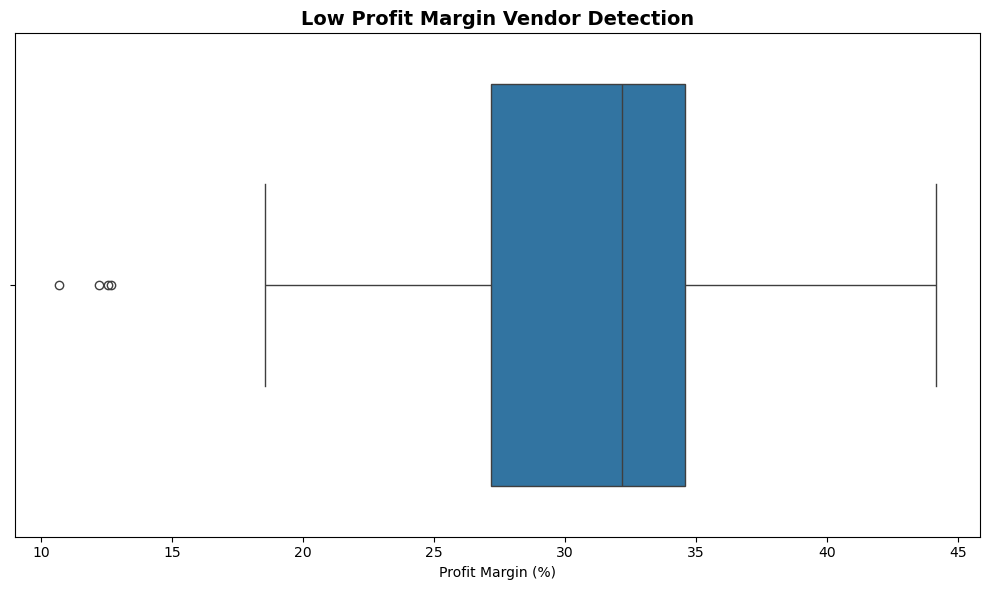

In [107]:
# Box Plot
plt.figure(figsize=(10,6))

sns.boxplot(
    x=vendor_profit["ProfitMargin"]
)

plt.title(
    "Low Profit Margin Vendor Detection",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Profit Margin (%)")

plt.tight_layout()

plt.show()

# **Business Impact:**

In [109]:
# Calculate revenue these vendors generate
low_margin_vendors["TotalSales"].sum()
# compare with total revenue
vendor_profit["TotalSales"].sum()
# impact
impact = (
    low_margin_vendors["TotalSales"].sum()
    /
    vendor_profit["TotalSales"].sum()
) * 100

print(f"Revenue Contribution: {impact:.2f}%")

Revenue Contribution: 0.09%


- **These low-margin vendors account for **0.09%** of total revenue.**

# **Outlier Summary**

| Metric                               |                           Value |
| ------------------------------------ | ------------------------------: |
| Vendors Analyzed                     |                         **125** |
| Outliers Identified                  |                           **4** |
| Percentage of Outliers               |                       **3.20%** 
| Lowest Profit Margin                 |                      **10.68%** |
| Highest Profit Margin Among Outliers |                      **12.67%** |
| Worst Performing Vendor              | **HOOD RIVER DISTILLERS, Inc.** |
| Lowest Recorded Margin               |                      **10.68%** |


# **Business Impact:**

- The IQR analysis identified **4** vendors **3.20%** of the supplier base with unusually low profit margins. However, these vendors contribute only **0.09%** of the company's total revenue, indicating that their overall financial impact on the business is minimal.

- Although these vendors operate below the acceptable profit margin threshold, their low sales volumes mean they do not represent a significant profitability risk to the organization. This suggests that the company's pricing and procurement strategies are performing effectively for the vast majority of revenue-generating vendors.

- Rather than implementing organization-wide pricing changes, management can address these vendors individually through targeted pricing reviews, supplier negotiations, or product portfolio assessments.

# **Exceptional Vendor Performance**

**Business Objective:**

- **Identify vendors that significantly outperform or underperform the rest of the supplier portfolio based on multiple business metrics.**

In [111]:
# Vendor Performance Scorecard
vendor_scorecard = vendor_profit.copy()

vendor_scorecard.head()

,VendorNo,VendorName,TotalSales,TotalCost,TotalProfit,ProfitMargin
0,60,ADAMBA IMPORTS INTL INC,704.53,537.68,166.85,23.682455
1,1703,ALISA CARR BEVERAGES,118167.38,77786.48,40380.90,34.172629
2,105,ALTAMAR BRANDS LLC,15748.75,11273.77,4474.98,28.414827
3,200,AMERICAN SPIRITS EXCHANGE,1719.97,960.39,759.58,44.162398
4,287,APPOLO VINEYARDS LLC,1616.92,1127.40,489.52,30.274844


In [112]:
# Classify Vendors
sales_q75 = vendor_scorecard["TotalSales"].quantile(0.75)
profit_q75 = vendor_scorecard["TotalProfit"].quantile(0.75)
margin_q75 = vendor_scorecard["ProfitMargin"].quantile(0.75)

sales_q25 = vendor_scorecard["TotalSales"].quantile(0.25)
profit_q25 = vendor_scorecard["TotalProfit"].quantile(0.25)
margin_q25 = vendor_scorecard["ProfitMargin"].quantile(0.25)

In [114]:
# Identify High Performers
high_performers = vendor_scorecard[
    (vendor_scorecard["TotalSales"] >= sales_q75) &
    (vendor_scorecard["TotalProfit"] >= profit_q75) &
    (vendor_scorecard["ProfitMargin"] >= margin_q75)
]

high_performers

,VendorNo,VendorName,TotalSales,TotalCost,TotalProfit,ProfitMargin
7,516,BANFI PRODUCTS CORP,1.928054e+06,1.175090e+06,752963.30,39.053024
22,1392,CONSTELLATION BRANDS INC,1.412123e+07,8.827902e+06,5293331.10,37.484908
25,1590,DIAGEO CHATEAU ESTATE WINES,2.176821e+06,1.368556e+06,808265.60,37.130543
31,3252,E & J GALLO WINERY,1.298266e+07,8.360375e+06,4622284.95,35.603527
50,4692,KOBRAND CORPORATION,2.834231e+06,1.795423e+06,1038807.69,36.652191
57,10000,MAJESTIC FINE WINES,5.374361e+06,3.391068e+06,1983293.06,36.902861
60,4425,MARTIGNETTI COMPANIES,3.178603e+07,2.038793e+07,11398092.27,35.858815
70,10754,PERFECTA WINES,7.714666e+06,5.046507e+06,2668159.08,34.585541
73,7153,PINE STATE TRADING CO,4.463721e+06,2.882247e+06,1581474.53,35.429511
92,2000,SOUTHERN WINE & SPIRITS NE,5.366228e+06,3.451202e+06,1915025.81,35.686629


In [115]:
# Identify Underperformers
underperformers = vendor_scorecard[
    (vendor_scorecard["TotalSales"] <= sales_q25) &
    (vendor_scorecard["TotalProfit"] <= profit_q25) &
    (vendor_scorecard["ProfitMargin"] <= margin_q25)
]

underperformers

,VendorNo,VendorName,TotalSales,TotalCost,TotalProfit,ProfitMargin
0,60,ADAMBA IMPORTS INTL INC,704.53,537.68,166.85,23.682455
8,1002,BERNIKO LLC,16.99,12.87,4.12,24.249559
9,90059,BLACK COVE BEVERAGES,6256.87,4926.62,1330.25,21.260630
10,2396,BLACK PRINCE DISTILLERY INC,9492.72,7432.88,2059.84,21.699155
44,3950,"HOOD RIVER DISTILLERS, Inc.",29403.29,26264.26,3139.03,10.675778
93,8663,STAR INDUSTRIES INC.,7770.86,6793.74,977.12,12.574155
113,9751,VINEDREA WINES LLC,11385.60,9996.80,1388.80,12.197864


In [116]:
# Summary
print(f"High Performers : {len(high_performers)}")
print(f"Underperformers : {len(underperformers)}")

High Performers : 15
Underperformers : 7


# **Business Impact:**

**High Performers Revenue:**

In [118]:
high_revenue = high_performers["TotalSales"].sum()

high_pct = (
    high_revenue /
    vendor_scorecard["TotalSales"].sum()
) * 100

print(f"Revenue from High Performers: {high_pct:.2f}%")

Revenue from High Performers: 37.73%


**Underperformers Revenue:**

In [119]:
low_revenue = underperformers["TotalSales"].sum()

low_pct = (
    low_revenue /
    vendor_scorecard["TotalSales"].sum()
) * 100

print(f"Revenue from Underperformers: {low_pct:.2f}%")

Revenue from Underperformers: 0.02%


In [123]:
# highperformering Vendors
high_performers.sort_values(
    by="TotalProfit",
    ascending=False
).head(10)

,VendorNo,VendorName,TotalSales,TotalCost,TotalProfit,ProfitMargin
60,4425,MARTIGNETTI COMPANIES,3.178603e+07,2.038793e+07,11398092.27,35.858815
22,1392,CONSTELLATION BRANDS INC,1.412123e+07,8.827902e+06,5293331.10,37.484908
31,3252,E & J GALLO WINERY,1.298266e+07,8.360375e+06,4622284.95,35.603527
70,10754,PERFECTA WINES,7.714666e+06,5.046507e+06,2668159.08,34.585541
57,10000,MAJESTIC FINE WINES,5.374361e+06,3.391068e+06,1983293.06,36.902861
92,2000,SOUTHERN WINE & SPIRITS NE,5.366228e+06,3.451202e+06,1915025.81,35.686629
96,8673,STE MICHELLE WINE ESTATES,4.902402e+06,3.039375e+06,1863026.78,38.002326
73,7153,PINE STATE TRADING CO,4.463721e+06,2.882247e+06,1581474.53,35.429511
123,9815,WINE GROUP INC,3.704001e+06,2.195393e+06,1508607.84,40.729142
107,9819,TREASURY WINE ESTATES,3.094305e+06,1.928632e+06,1165672.62,37.671548


In [121]:
# Underperforming Vendors
underperformers.sort_values(
    by="TotalProfit"
).head(10)

,VendorNo,VendorName,TotalSales,TotalCost,TotalProfit,ProfitMargin
8,1002,BERNIKO LLC,16.99,12.87,4.12,24.249559
0,60,ADAMBA IMPORTS INTL INC,704.53,537.68,166.85,23.682455
93,8663,STAR INDUSTRIES INC.,7770.86,6793.74,977.12,12.574155
9,90059,BLACK COVE BEVERAGES,6256.87,4926.62,1330.25,21.260630
113,9751,VINEDREA WINES LLC,11385.60,9996.80,1388.80,12.197864
10,2396,BLACK PRINCE DISTILLERY INC,9492.72,7432.88,2059.84,21.699155
44,3950,"HOOD RIVER DISTILLERS, Inc.",29403.29,26264.26,3139.03,10.675778


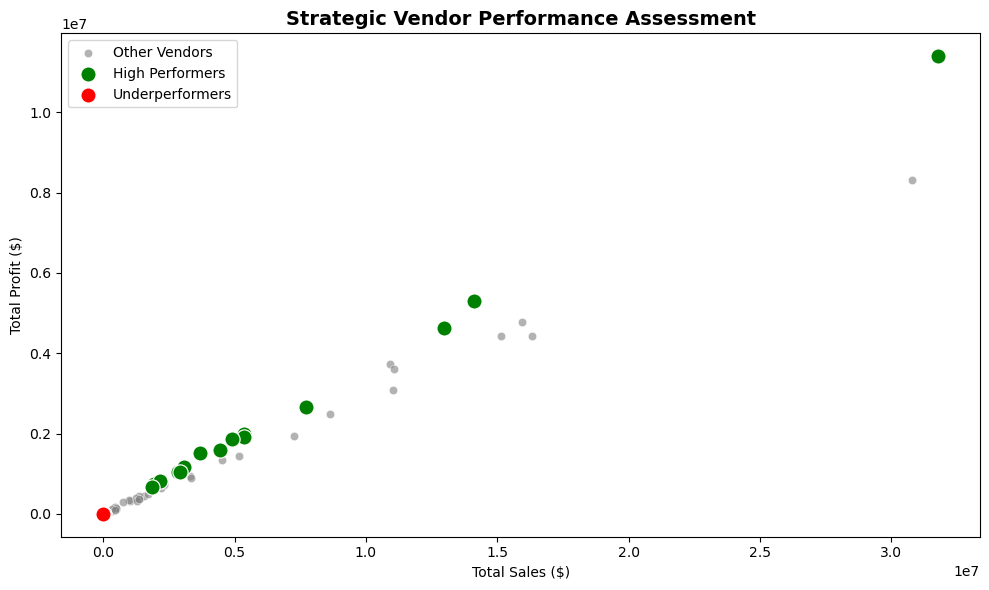

In [125]:
# highperformers vs underperformers
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=vendor_scorecard,
    x="TotalSales",
    y="TotalProfit",
    alpha=0.6,
    color="gray",
    label="Other Vendors"
)

sns.scatterplot(
    data=high_performers,
    x="TotalSales",
    y="TotalProfit",
    color="green",
    s=120,
    label="High Performers"
)

sns.scatterplot(
    data=underperformers,
    x="TotalSales",
    y="TotalProfit",
    color="red",
    s=120,
    label="Underperformers"
)

plt.title(
    "Strategic Vendor Performance Assessment",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Total Profit ($)")

plt.legend()

plt.tight_layout()
plt.show()

# **Business Insight:**

- The analysis identified **15** strategically important vendors that contribute **37.73%** of the company's total revenue, despite representing only **12%** of the supplier base (15 out of 125 vendors). This demonstrates that a relatively small number of suppliers generate a substantial share of business value.

- Notable high-performing vendors include:

**1.  MARTIGNETTI COMPANIES**     
**2.  CONSTELLATION BRANDS INC**          
**3.  E & J GALLO WINERY**       
**4.  PERFECTA WINES**            
**5.  MAJESTIC FINE WINES**

- These vendors consistently achieve high sales, strong profitability, and healthy profit margins, making them key contributors to the organization's financial performance.

- Conversely, 7 vendors were identified as underperformers. Together, they contribute only **0.02%** of total revenue, indicating that their impact on overall business performance is negligible.

- This suggests that the company's supplier portfolio is highly concentrated around a small number of high-value vendors, while the weakest-performing vendors have minimal influence on financial outcomes.

# **4: Hypothesis Testing**

# **Does Bulk Purchasing Reduce Unit Cost?**

**Business Objective:**

- **Determine whether bulk purchasing leads to significantly lower unit purchase prices.**

In [126]:
# Create Purchase Groups
median_qty = purchases["Quantity"].median()

bulk_purchase = purchases[
    purchases["Quantity"] >= median_qty
]

small_purchase = purchases[
    purchases["Quantity"] < median_qty
]

print("Median Quantity:", median_qty)

Median Quantity: 10.0


In [127]:
# Compare Average Purchase Price
print("Average Price (Bulk Purchases):",
      bulk_purchase["PurchasePrice"].mean())

print("Average Price (Small Purchases):",
      small_purchase["PurchasePrice"].mean())

Average Price (Bulk Purchases): 9.845444898891772
Average Price (Small Purchases): 14.624276003278249


# **Hypotheses:**
**Null Hypothesis (H₀):**
There is no significant difference in unit purchase prices between bulk purchases and small purchases.

**Alternative Hypothesis (H₁):**
Bulk purchases have significantly lower unit purchase prices.

In [128]:
# Check Normality
from scipy.stats import normaltest

stat_bulk, p_bulk = normaltest(bulk_purchase["PurchasePrice"])
stat_small, p_small = normaltest(small_purchase["PurchasePrice"])

print("Bulk Purchase p-value :", p_bulk)
print("Small Purchase p-value:", p_small)

Bulk Purchase p-value : 0.0
Small Purchase p-value: 0.0


In [129]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    bulk_purchase["PurchasePrice"],
    small_purchase["PurchasePrice"],
    alternative="less"
)

print(f"Statistic : {stat:.2f}")
print(f"P-value   : {p:.5f}")

Statistic : 495344942349.00
P-value   : 0.00000


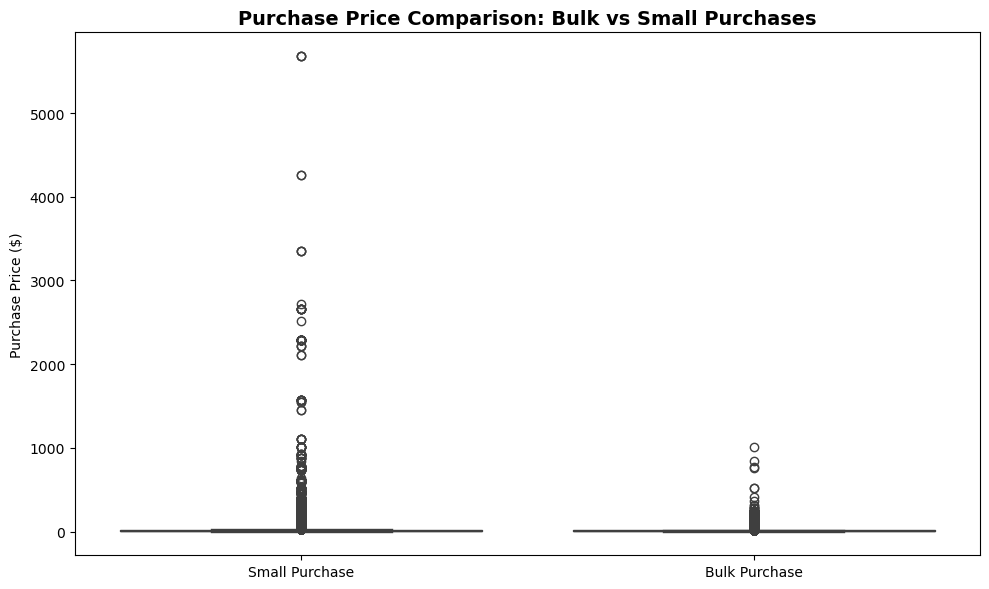

In [130]:
comparison = purchases.copy()

comparison["PurchaseType"] = comparison["Quantity"].apply(
    lambda x: "Bulk Purchase" if x >= median_qty else "Small Purchase"
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=comparison,
    x="PurchaseType",
    y="PurchasePrice"
)

plt.title(
    "Purchase Price Comparison: Bulk vs Small Purchases",
    fontsize=14,
    weight="bold"
)

plt.xlabel("")
plt.ylabel("Purchase Price ($)")

plt.tight_layout()
plt.show()

# **Statistical Interpretation:**

- Both purchase groups failed the normality test (p < 0.001), indicating that purchase prices are not normally distributed. Therefore, the Mann–Whitney U test, a non-parametric alternative to the independent samples t-test, was used.

- The test produced a p-value less than 0.001, providing strong statistical evidence that purchase prices differ significantly between bulk and small - purchases.

- Since the average purchase price for bulk purchases **9.85** is substantially lower than that of small purchases **14.62**, the analysis supports the conclusion that purchasing in larger quantities is associated with lower unit costs.

# **Business Insight:**

- The hypothesis test confirms that **bulk purchasing is an effective procurement strategy for reducing unit costs**. Products purchased in quantities of **10 units or more** have an average purchase price of **9.85**, compared to **14.62** for smaller purchases, representing an average cost reduction of **32.6%**.

- The **Mann–Whitney U test (p < 0.001)** indicates that this difference is statistically significant, providing strong evidence that larger purchase volumes are associated with lower unit costs rather than random variation.

- The box plot further reinforces this finding by showing that bulk purchases have a **lower median purchase price**, while small purchases exhibit **greater price variability** and contain a higher number of expensive transactions. These results suggest that suppliers provide meaningful volume discounts for larger orders.

- From a business perspective, the company can reduce procurement costs by consolidating purchase orders where demand is stable. However, purchasing decisions should also consider inventory holding costs to ensure that savings from bulk discounts are not offset by excess inventory.

# **Do High-Performing Vendors Have Higher Profit Margins?**

**Business Objective:**

- **Determine whether high-performing vendors consistently achieve higher profit margins than the remaining vendors.**

In [131]:
# Create Groups
other_vendors = vendor_scorecard[
    ~vendor_scorecard["VendorNo"].isin(high_performers["VendorNo"])
]

print("High Performers :", len(high_performers))
print("Other Vendors   :", len(other_vendors))

High Performers : 15
Other Vendors   : 108


In [132]:
# Compare Average Profit Margin
print(
    "Average Margin (High Performers):",
    round(high_performers["ProfitMargin"].mean(),2)
)

print(
    "Average Margin (Other Vendors):",
    round(other_vendors["ProfitMargin"].mean(),2)
)

Average Margin (High Performers): 36.88
Average Margin (Other Vendors): 29.63


In [133]:
# Check Normality
from scipy.stats import shapiro

stat1, p1 = shapiro(high_performers["ProfitMargin"])

stat2, p2 = shapiro(other_vendors["ProfitMargin"])

print("High Performers p-value :", p1)
print("Other Vendors p-value :", p2)

High Performers p-value : 0.30218144541968117
Other Vendors p-value : 0.0025133146926548315


**If both p-values are lesser than 0.05
Use Mann–Whitney U**

In [134]:
# Mann–Whitney U Test
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    high_performers["ProfitMargin"],
    other_vendors["ProfitMargin"],
    alternative="greater"
)

print(f"Statistic : {stat:.2f}")
print(f"P-value   : {p:.5f}")

Statistic : 1487.00
P-value   : 0.00000


In [135]:
alternative="greater"

**because our hypothesis is that high-performing vendors have higher profit margins**

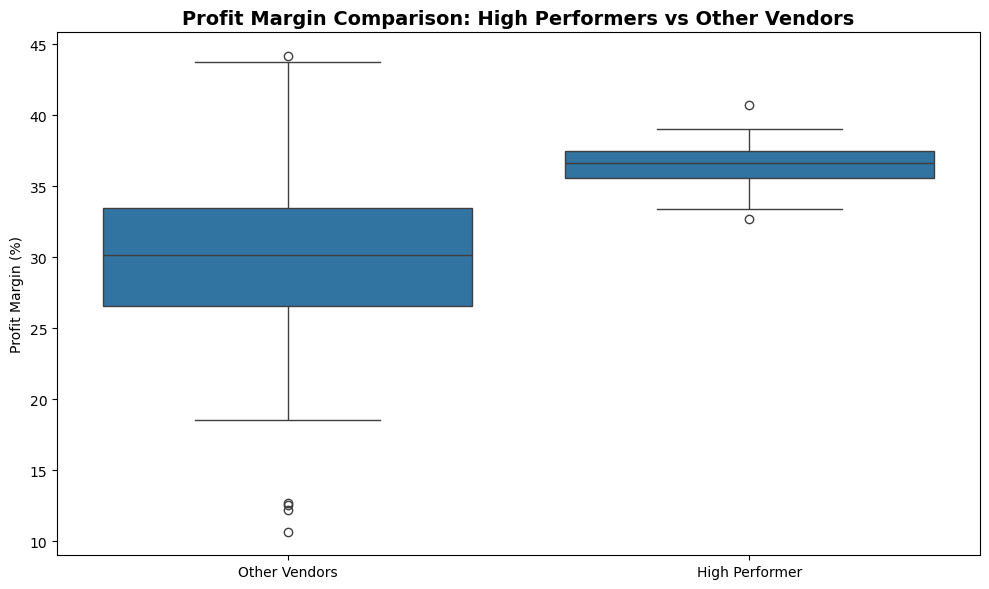

In [137]:
#box plot
comparison = vendor_scorecard.copy()

comparison["VendorGroup"] = comparison["VendorNo"].apply(
    lambda x: "High Performer"
    if x in high_performers["VendorNo"].values
    else "Other Vendors"
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=comparison,
    x="VendorGroup",
    y="ProfitMargin"
)

plt.title(
    "Profit Margin Comparison: High Performers vs Other Vendors",
    fontsize=14,
    weight="bold"
)

plt.xlabel("")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()

plt.show()

# **Statistical Interpretation:**

- The Shapiro–Wilk normality test showed that high-performing vendors follow an approximately normal distribution (p = 0.302), while other vendors do not (p = 0.0025). Since at least one group violated the normality assumption, the Mann–Whitney U test was selected.

- The Mann–Whitney U test produced a p-value less than **0.001**, indicating a statistically significant difference in profit margins between the two groups.

- Therefore, the null hypothesis is rejected, confirming that high-performing vendors consistently achieve higher profit margins than the rest of the supplier portfolio.

# **Business Insight:**

- The hypothesis test confirms that **high-performing vendors consistently generate higher profit margins than the remaining supplier base**.

- High-performing vendors achieve an average profit margin of **36.88%**, compared to **29.63%** for other vendors, representing an improvement of approximately **24.5%** in profitability.

- The **Mann–Whitney U test (p < 0.001)** indicates that this difference is statistically significant, demonstrating that the higher margins are unlikely to be due to random variation.

- The box plot further supports this finding by showing that high-performing vendors have a **higher median profit margin** and a **more consistent distribution**, whereas other vendors exhibit greater variability and include several low-margin outliers.

- These findings suggest that the company's highest-performing vendors are not only generating greater sales and profits but are also operating with superior pricing efficiency and healthier profit margins. Strengthening partnerships with these vendors can contribute to sustained revenue growth and improved overall profitability.

# **5: Confidence Intervals**

# **Average Profit Margin**

**Business Objective:**

- **Estimate the range within which the company's true average vendor profit margin is likely to fall.**

In [139]:
#Required Library
from scipy.stats import t
import numpy as np

In [140]:
# Calculate Statistics
margin = vendor_profit["ProfitMargin"]

n = len(margin)

mean = margin.mean()

std = margin.std()

print(f"Sample Size : {n}")
print(f"Mean : {mean:.2f}%")
print(f"Standard Deviation : {std:.2f}")

Sample Size : 125
Mean : 30.55%
Standard Deviation : 6.31


In [141]:
# Standard Error
standard_error = std / np.sqrt(n)

print(f"Standard Error : {standard_error:.3f}")

Standard Error : 0.565


In [142]:
# 95% Confidence Interval
confidence = 0.95

ci = t.interval(
    confidence,
    df=n-1,
    loc=mean,
    scale=standard_error
)

print(f"95% Confidence Interval: ({ci[0]:.2f}%, {ci[1]:.2f}%)")

95% Confidence Interval: (29.43%, 31.67%)


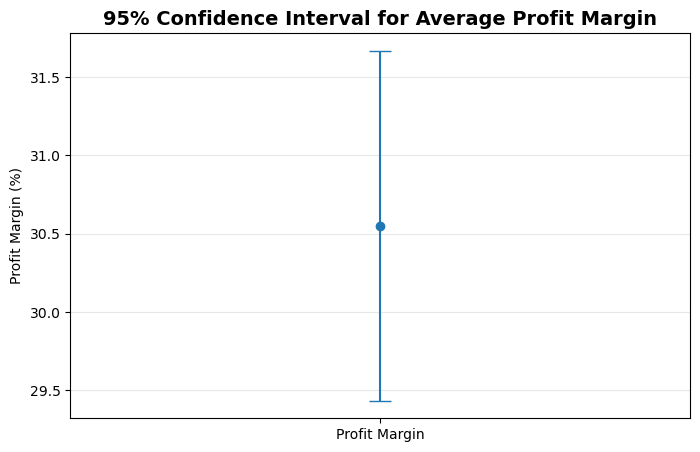

In [144]:
# confidence interval plot
plt.figure(figsize=(8,5))

plt.errorbar(
    x=1,
    y=mean,
    yerr=[[mean-ci[0]], [ci[1]-mean]],
    fmt='o',
    capsize=8
)

plt.xticks([1], ["Profit Margin"])

plt.ylabel("Profit Margin (%)")

plt.title(
    "95% Confidence Interval for Average Profit Margin",
    fontsize=14,
    weight="bold"
)

plt.grid(axis="y", alpha=0.3)

plt.show()

# **Statistical Interpretation:**

- A **95%** confidence interval was calculated using the sample mean and Student's t-distribution.

- The analysis estimates that the true average profit margin of the company's vendor portfolio lies between **29.43%** and **31.67%** with **95%** confidence.

- The relatively narrow confidence interval (only 2.24 percentage points wide) indicates that the estimated average profit margin is precise and reliable.

# **Business Insight:**

- The confidence interval analysis estimates that the company's **true average vendor profit margin** lies between **29.43% and 31.67%** with **95% confidence**.

- The sample average profit margin of **30.55%** falls near the center of this interval, indicating that it is a reliable estimate of the overall profitability across the vendor portfolio.

- The relatively narrow confidence interval demonstrates low sampling uncertainty, suggesting that vendor profitability is measured with a high degree of precision. This provides management with greater confidence when using the average profit margin as a benchmark for evaluating supplier performance and setting profitability targets.

- Overall, the analysis indicates that the business can reasonably expect vendor profit margins to remain close to **30%**, supporting informed pricing, procurement, and financial planning decisions.

# **Confidence Interval for Average Purchase Price**

**Business Objective:**

- **Estimate the range within which the company's true average purchase price is expected to lie with 95% confidence.**

In [145]:
# Calculate Statistics
from scipy.stats import t
import numpy as np

purchase_price = purchases["PurchasePrice"]

n = len(purchase_price)

mean = purchase_price.mean()

std = purchase_price.std()

print(f"Sample Size : {n:,}")
print(f"Mean : ${mean:.2f}")
print(f"Standard Deviation : {std:.2f}")

Sample Size : 2,372,474
Mean : $12.05
Standard Deviation : 17.95


In [146]:
# Standard Error
standard_error = std / np.sqrt(n)

print(f"Standard Error : {standard_error:.4f}")

Standard Error : 0.0117


In [147]:
#95% Confidence Interval
confidence = 0.95

ci = t.interval(
    confidence,
    df=n-1,
    loc=mean,
    scale=standard_error
)

print(f"95% Confidence Interval: (${ci[0]:.2f}, ${ci[1]:.2f})")

95% Confidence Interval: ($12.03, $12.07)


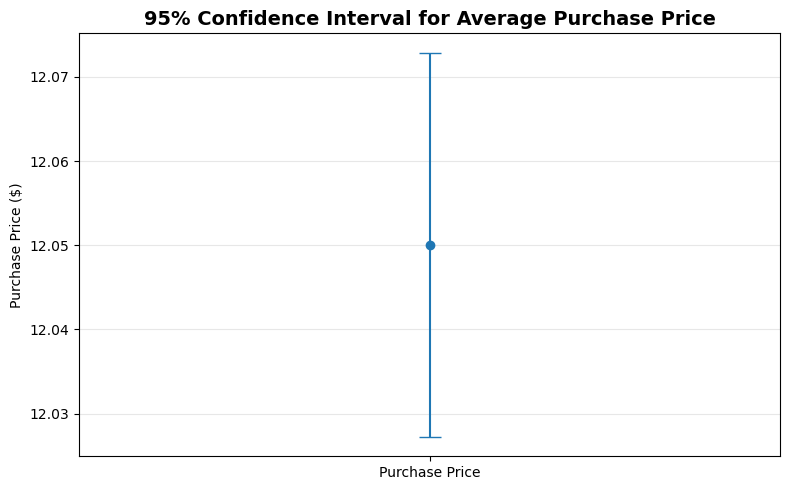

In [149]:
# confidence interval plot
plt.figure(figsize=(8,5))

plt.errorbar(
    x=1,
    y=mean,
    yerr=[[mean-ci[0]], [ci[1]-mean]],
    fmt='o',
    capsize=8
)

plt.xticks([1], ["Purchase Price"])

plt.ylabel("Purchase Price ($)")

plt.title(
    "95% Confidence Interval for Average Purchase Price",
    fontsize=14,
    weight="bold"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# **Statistical Interpretation:**

- A 95% confidence interval was calculated using the sample mean and Student's t-distribution.

- Based on **2,372,474** purchase transactions, the analysis estimates that the company's true average purchase price lies between **12.03** and **12.07** with 95% confidence.

- The extremely narrow confidence interval (only $0.04 wide) indicates a highly precise estimate. This level of precision is expected due to the large sample size, which substantially reduces sampling uncertainty.

# **Business Insight**

- The confidence interval analysis estimates that the company's **true average purchase price** lies between **$12.03 and $12.07** with **95% confidence**.

- Based on more than **2.37 million purchase transactions**, the sample average purchase price of **$12.05** provides a highly reliable estimate of the organization's procurement costs.

- The extremely narrow confidence interval demonstrates minimal sampling uncertainty, indicating that the purchase price remains remarkably stable across the dataset. This provides management with a dependable benchmark for budgeting, procurement planning, supplier negotiations, and future cost forecasting.

- Overall, the analysis suggests that the business can confidently use **approximately $12 per unit** as the expected average purchase price when evaluating purchasing performance and monitoring procurement efficiency.

# **6: Statistical Findings & Business Conclusions**

# **Business Objective 1: Evaluate Vendor Performance**
**Key Findings:**
- Vendor sales and profits showed an extremely strong positive correlation (r = 0.99), indicating that vendors generating higher sales also generate higher profits.
- Strategic vendor assessment identified 15 high-performing vendors responsible for 37.73% of total revenue.
Only 7 vendors were classified as underperformers, contributing just 0.02% of total revenue.


**Business Conclusion:**
- The company's revenue is concentrated among a relatively small group of high-performing vendors. Maintaining strong relationships with these suppliers is critical for sustaining revenue growth and overall profitability.

# **Business Objective 2: Optimize Purchasing Strategy**
**Key Findings:**
- Purchase Quantity and Purchase Price exhibited a negative correlation, indicating that larger purchases tend to reduce unit costs.
- The Mann–Whitney U test confirmed that bulk purchasing significantly lowers purchase prices (p < 0.001).
- Bulk purchases averaged 9.85 per unit, compared with 14.62 for smaller purchases.
  
**Business Conclusion:**

- Bulk purchasing is an effective procurement strategy that significantly reduces procurement costs.

# **Business Objective 3: Improve Inventory Management**
**Key Findings:**
- Inventory levels showed a strong positive correlation with sales (r = 0.844).
- Inventory value distribution was highly right-skewed.
- 901 products (9.33%) were identified as high-value inventory outliers.

**Business Conclusion:**

- Although inventory generally supports sales demand, a relatively small number of products account for a disproportionately large share of inventory investment.

# **Business Objective 4: Improve Profitability**
**Key Findings:**
- High-performing vendors achieved an average profit margin of 36.88%, compared with 29.63% for other vendors.
- The difference was statistically significant (p < 0.001).
- The overall vendor profit margin was estimated at 30.55%, with a 95% confidence interval of 29.43%–31.67%.
  
**Business Conclusion:**

- The company's strongest vendors consistently deliver higher profitability, demonstrating that supplier selection has a measurable impact on financial performance.

# **Business Objective 5: Support Data-Driven Decision Making**
**Key Findings:**
- Statistical analyses consistently produced significant results supporting the business objectives.
- Confidence intervals for both purchase price and profit margin were narrow, indicating highly reliable estimates.
- Distribution and outlier analyses identified areas requiring management attention while confirming the stability of overall business performance.

**Business Conclusion:**

- The company's operational data provides a strong foundation for evidence-based procurement, inventory, and supplier management decisions.